<a href="https://colab.research.google.com/github/CarlosMendez1997Sei/WETSAT_v2/blob/main/2_Modelling_WETSAT_Google_Colab/User_Version_Random_Forest_WetSAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

	Google Colaboratory
	PostgreSQL
	GitHub	     
	Wetlands flooding extent and trends using SATellite data and Machine Learning WETSAT
	Code Developed by
	Carlos Mendez
	Sebastian Palomino
	David Zamora  

# Install packages and libraries used in WETSAT

In [1]:
###################################### Artificial Intelligence Frameworks #####################################################
# scikit-learn Framework
!pip install scikit-learn
###################################### Data, Geoprocessing and Graphics libraries #####################################################
!pip install rasterio
!pip install matplotlib
!pip install numpy
!pip install contextily

# Import libraries and packages

In [3]:
## AI packages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

## Geoprocessing packages
import rasterio
from rasterio.features import rasterize
from matplotlib.colors import ListedColormap
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import gc  # Garbage collector to free memory
import os
import glob
import contextily as ctx
from shapely.geometry import box
import seaborn as sns
import joblib
import urllib.request
import warnings
from collections import Counter
from google.colab import files
from google.colab import data_table

# Create Buttoms and import files

## Create Buttom to upload VH Images

In [18]:
# Define vh_path
vh_path = "/content/WetSAT/VH"

# Create vh path if doesn't exist
os.makedirs(vh_path, exist_ok=True)

# Upload files
uploadvh = files.upload()

# Store files in the VH path
for filename, content in uploadvh.items():
    file_path = os.path.join(vh_path, filename)
    with open(file_path, "wb") as f:
        f.write(content)
    print(f"Files stored in: {file_path}")

Saving gamma_dB_20240113_VH_sample.tif to gamma_dB_20240113_VH_sample.tif
Saving gamma_dB_20240125_VH_sample.tif to gamma_dB_20240125_VH_sample.tif
Saving gamma_dB_20240206_VH_sample.tif to gamma_dB_20240206_VH_sample.tif
Saving gamma_dB_20240218_VH_sample.tif to gamma_dB_20240218_VH_sample.tif
Saving gamma_dB_20240301_VH_sample.tif to gamma_dB_20240301_VH_sample.tif
Archivo guardado en: /content/WetSAT/VH/gamma_dB_20240113_VH_sample.tif
Archivo guardado en: /content/WetSAT/VH/gamma_dB_20240125_VH_sample.tif
Archivo guardado en: /content/WetSAT/VH/gamma_dB_20240206_VH_sample.tif
Archivo guardado en: /content/WetSAT/VH/gamma_dB_20240218_VH_sample.tif
Archivo guardado en: /content/WetSAT/VH/gamma_dB_20240301_VH_sample.tif


## Create Buttom to upload VV Images

In [19]:
# Define vv_path
vv_path = "/content/WetSAT/VV"

# Create vv path if doesn't exist
os.makedirs(vv_path, exist_ok=True)

# Upload files
uploadvv = files.upload()

# Store files in the VH path
for filename, content in uploadvv.items():
    file_path = os.path.join(vv_path, filename)
    with open(file_path, "wb") as f:
        f.write(content)
    print(f"Files stored in: {file_path}")

Saving gamma_dB_20240113_VH_sample.tif to gamma_dB_20240113_VH_sample.tif
Saving gamma_dB_20240125_VH_sample.tif to gamma_dB_20240125_VH_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240113_VH_sample.tif
Files stored in: /content/WetSAT/VV/gamma_dB_20240125_VH_sample.tif


# Import the Random Forest Model and Labels/Marks

In [ ]:
# Create backup from GitHub to upload and reload RF model if system restarted
# Load model
model_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/best_multi_rf_model_backup.pkl"
urllib.request.urlretrieve(model_url, "best_multi_rf_model.pkl")
best_model = joblib.load("best_multi_rf_model.pkl")

# Load encoders
encoder_url = "https://raw.githubusercontent.com/sei-latam/WETSAT_v2/main/2_Modelling_WETSAT_Google_Colab/label_encoders_backup.pkl"
urllib.request.urlretrieve(encoder_url, "label_encoders.pkl")
label_encoders = joblib.load("label_encoders.pkl")

### Calculate the PR index in new AOI

In [ ]:
## Access the VH Path
vh_path = "/content/WETSAT_v2/0_Original_Files/aoi3/VH"
## Access the VV Path
vv_path = "/content/WETSAT_v2/0_Original_Files/aoi3/VV"
## Create the PR Index path
pr_path = "/content/WETSAT_v2/0_Original_Files/aoi3/PR_index"

# Create output directory if it doesn't exist
os.makedirs(pr_path, exist_ok=True)

# List VH and VV files (assuming matching filenames)
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")]) # Search files ending with .tif
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")]) # Search files ending with .tif

# Loop through files and compute PR index scaled between 0 and 1
for vh_file, vv_file in zip(vh_files, vv_files):
    # Read the vh_files and vv_files
    with rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(vv_path, vv_file)) as vv_src:

        vh = vh_src.read(1).astype("float32") # Converts the data to 32-bit float
        vv = vv_src.read(1).astype("float32") # Converts the data to 32-bit float

        pr_index_diff = vh - vv  # Compute PR index as difference

        # Save PR index difference
        profile = vh_src.profile
        profile.update(dtype="float32", count=1)

        pr_filename = f"PR_diff_{vh_file}"
        with rasterio.open(os.path.join(pr_path, pr_filename), "w", **profile) as dst:
            dst.write(pr_index_diff, 1)

print("PR index (VH - VV) computation complete.")

PR index (VH - VV) computation complete.


### Import the RF model

In [ ]:
rf_model = joblib.load("/content/WETSAT_v2/models/Model_Random_Forest.pkl")
le = joblib.load("/content/WETSAT_v2/models/Labels_Random_Forest.pkl")

In [ ]:
vv_files = sorted([f for f in os.listdir(vv_path) if f.endswith(".tif")])
vh_files = sorted([f for f in os.listdir(vh_path) if f.endswith(".tif")])
pr_files = sorted([f for f in os.listdir(pr_path) if f.endswith(".tif")])

assert len(vv_files) == len(vh_files) == len(pr_files), "The size of VV, VH and PR must be equal (size)"

In [ ]:
def predict_and_save(vv_file, vh_file, pr_file, model, encoder, index):
    with rasterio.open(os.path.join(vv_path, vv_file)) as vv_src, \
         rasterio.open(os.path.join(vh_path, vh_file)) as vh_src, \
         rasterio.open(os.path.join(pr_path, pr_file)) as pr_src:

        vv = vv_src.read(1)
        vh = vh_src.read(1)
        pr = pr_src.read(1)

        assert vv.shape == vh.shape == pr.shape, "size verification"

        # Detect NoData mask (assuming all bands share the same mask)
        nodata_val = vv_src.nodata
        valid_mask = (vv != nodata_val) & (vh != nodata_val) & (pr != nodata_val)

        stacked = np.stack([vh, vv, pr], axis=-1)
        shape = stacked.shape[:2]
        flat_pixels = stacked.reshape(-1, 3)

        # Apply mask to valid pixels
        flat_mask = valid_mask.flatten()
        valid_pixels = flat_pixels[flat_mask]

        # Predict only on valid pixels
        pred_encoded = model.predict(valid_pixels)

        # Create full prediction array filled with nodata (255)
        pred_numeric = np.full(flat_mask.shape, 255, dtype=np.uint8)
        pred_numeric[flat_mask] = pred_encoded
        pred_numeric = pred_numeric.reshape(shape)

        # Stored classification using the original name (for example from VV path)
        base_name = os.path.splitext(vv_file)[0]   # remove temporal extension of .tif
        output_path = f"Classification_RF_{base_name}.tif"

        # Save prediction raster
        profile = vv_src.profile
        profile.update(dtype=rasterio.uint8, count=1, nodata=255)

        with rasterio.open(output_path, "w", **profile) as dst:
            dst.write(pred_numeric, 1)

        print(f"✅ Image stored as: {output_path}")

In [ ]:
for i in range(len(vv_files)):
    predict_and_save(vv_files[i], vh_files[i], pr_files[i], rf_model, le, i)

✅ Image stored as: Classification_RF_20180101_VV.tif
✅ Image stored as: Classification_RF_20180113_VV.tif
✅ Image stored as: Classification_RF_20180125_VV.tif
✅ Image stored as: Classification_RF_20180206_VV.tif
✅ Image stored as: Classification_RF_20180218_VV.tif
✅ Image stored as: Classification_RF_20180302_VV.tif
✅ Image stored as: Classification_RF_20180314_VV.tif
✅ Image stored as: Classification_RF_20180326_VV.tif
✅ Image stored as: Classification_RF_20180407_VV.tif
✅ Image stored as: Classification_RF_20180419_VV.tif
✅ Image stored as: Classification_RF_20180501_VV.tif
✅ Image stored as: Classification_RF_20180513_VV.tif
✅ Image stored as: Classification_RF_20180525_VV.tif
✅ Image stored as: Classification_RF_20180606_VV.tif
✅ Image stored as: Classification_RF_20180618_VV.tif
✅ Image stored as: Classification_RF_20180630_VV.tif
✅ Image stored as: Classification_RF_20180712_VV.tif
✅ Image stored as: Classification_RF_20180724_VV.tif
✅ Image stored as: Classification_RF_20180805_

In [ ]:
def area_by_class_meters(raster_path, nodata=255, class_map=None):
    with rasterio.open(raster_path) as src:
        data = src.read(1)
        transform = src.transform
        res_x = transform.a
        res_y = -transform.e
        pixel_area_m2 = abs(res_x) * abs(res_y)

        # Use Valid Mask
        if src.nodata is not None:
            nodata = src.nodata
        valid = data != nodata

        # Calculate number of pixels by label
        vals = data[valid].ravel()
        counts = Counter(vals.tolist())

    # Base name of files
    raster_name = os.path.basename(raster_path)

    # Convert to km² and store data
    records = []
    for code, n in counts.items():
        area_km2 = (n * pixel_area_m2) / 1_000_000.0
        etiqueta = class_map.get(code, str(code)) if class_map else str(code)
        records.append({
            "archivo": raster_name,
            "code": code,
            "etiqueta": etiqueta,
            "pixeles": n,
            "area_km2": area_km2
        })

    df = pd.DataFrame(records).sort_values("code").reset_index(drop=True)
    total_km2 = df["area_km2"].sum()
    return df, total_km2

In [ ]:
class_map = {i: cls for i, cls in enumerate(le.classes_)}

# Search all .tif files of classification
paths = sorted(glob.glob("Classification_RF_*.tif"))

resumen = []
for p in paths:
    df_area, total = area_by_class_meters(p, nodata=255, class_map=class_map)
    resumen.append(df_area)

# Concatenate all results
resumen_df = pd.concat(resumen, ignore_index=True)

# show the final dataframe
print(resumen_df)

# Export dataframe to csv file
resumen_df.to_csv("area_by_class.csv", index=False)
print("📄 csv file exported as 'area_by_class.csv'")

                               archivo  code etiqueta  pixeles   area_km2
0    Classification_RF_20180101_VV.tif     0      e11     6886     6.1974
1    Classification_RF_20180101_VV.tif     2      e13    15130    13.6170
2    Classification_RF_20180101_VV.tif     3      e21  4224830  3802.3470
3    Classification_RF_20180101_VV.tif     4      e22  5355652  4820.0868
4    Classification_RF_20180101_VV.tif     5      e23   248052   223.2468
..                                 ...   ...      ...      ...        ...
179  Classification_RF_20181227_VV.tif     1      e12        1     0.0009
180  Classification_RF_20181227_VV.tif     2      e13     9692     8.7228
181  Classification_RF_20181227_VV.tif     3      e21  4033532  3630.1788
182  Classification_RF_20181227_VV.tif     4      e22  5626707  5064.0363
183  Classification_RF_20181227_VV.tif     5      e23   175356   157.8204

[184 rows x 5 columns]
📄 Informe exportado como 'informe_areas_por_clase.csv'


In [ ]:
def visualizar_pronosticos_coloreado(folder_path, label_encoder, label_colors, nodata=255, images_per_fig=6):
    tif_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.tif')])
    num_files = len(tif_files)

    # Transform integer and numbers to labels
    code_to_label = {i: label for i, label in enumerate(label_encoder.classes_)}
    cmap_colors = [label_colors.get(code_to_label[i], "#FFFFFF") for i in range(len(code_to_label))]
    cmap = ListedColormap(cmap_colors)

    for i in range(0, num_files, images_per_fig):
        fig, axes = plt.subplots(1, images_per_fig, figsize=(18, 3))
        axes = axes.flatten()

        for j in range(images_per_fig):
            idx = i + j
            if idx < num_files:
                filename = tif_files[idx]
                with rasterio.open(os.path.join(folder_path, filename)) as src:
                    data = src.read(1)
                    if src.nodata is not None:
                        nodata = src.nodata
                    data = np.ma.masked_equal(data, nodata)

                    im = axes[j].imshow(data, cmap=cmap, interpolation='none', vmin=0, vmax=len(code_to_label)-1)
                    axes[j].set_title(filename, fontsize=8)
                    axes[j].axis('off')

                    cbar = fig.colorbar(im, ax=axes[j], shrink=1.0, ticks=np.arange(len(code_to_label)))
                    cbar.ax.set_yticklabels([code_to_label[i] for i in range(len(code_to_label))])
            else:
                axes[j].axis('off')

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [ ]:
label_colors = {
    'e11': '#A7D98D',  # Non-water – Sparse vegetation
    'e12': '#E8D8A8',  # Non-water – No vegetation
    'e13': '#2E7D32',  # Non-water – Dense vegetation
    'e21': '#76C9CC',  # Water – Sparse vegetation
    'e22': '#1E88E5',  # Water – No vegetation (open water)
    'e23': '#006D6F'   # Water – Dense vegetation
}

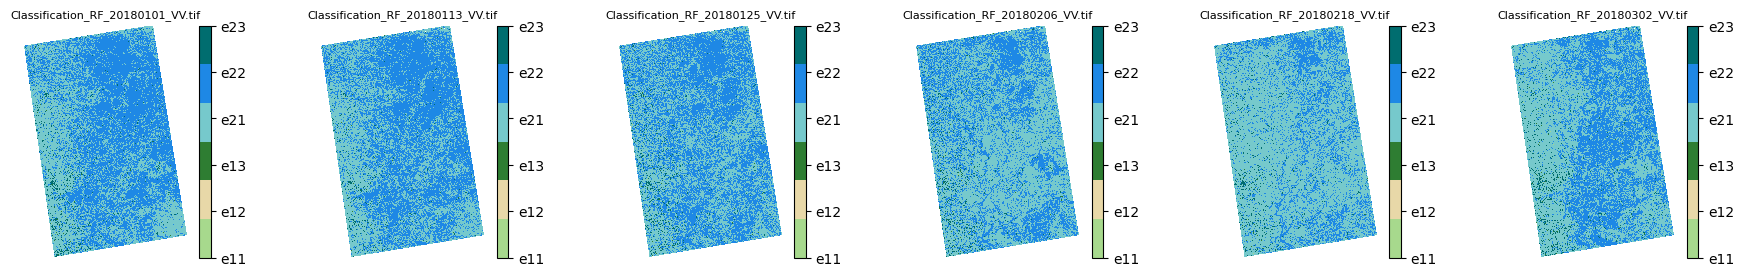

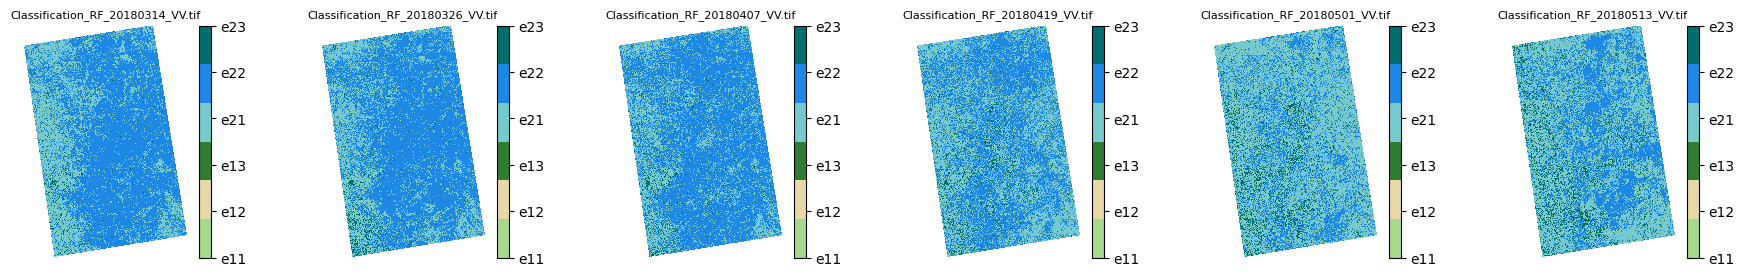

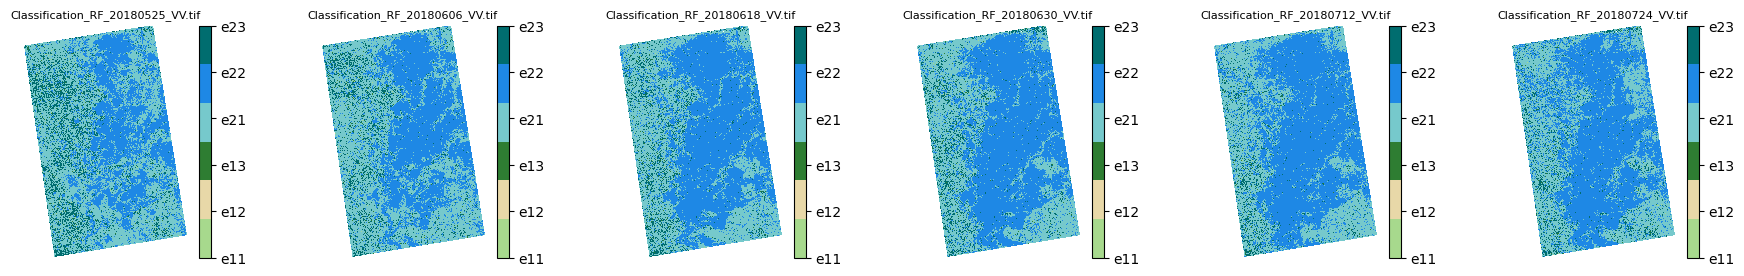

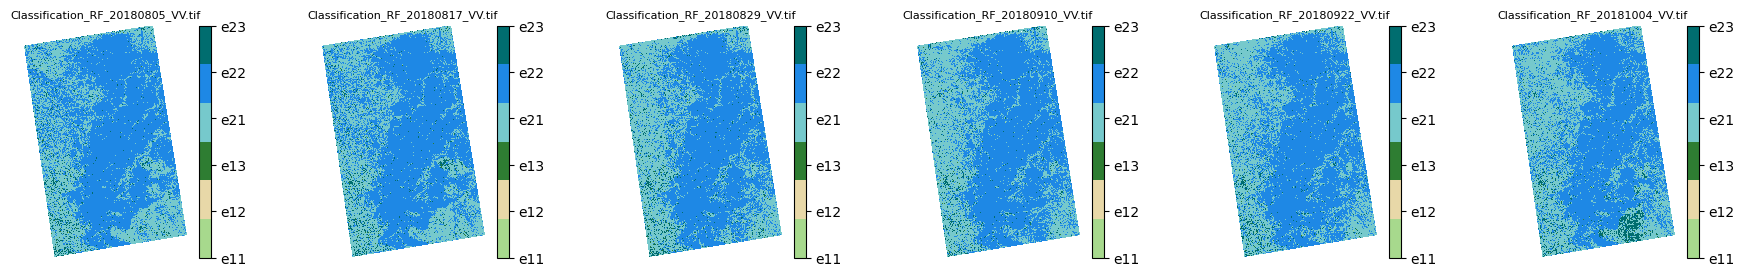

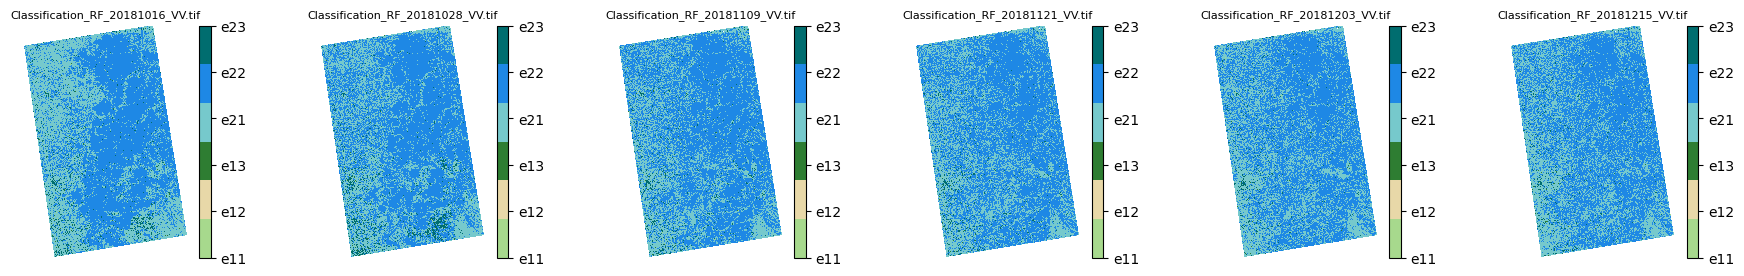

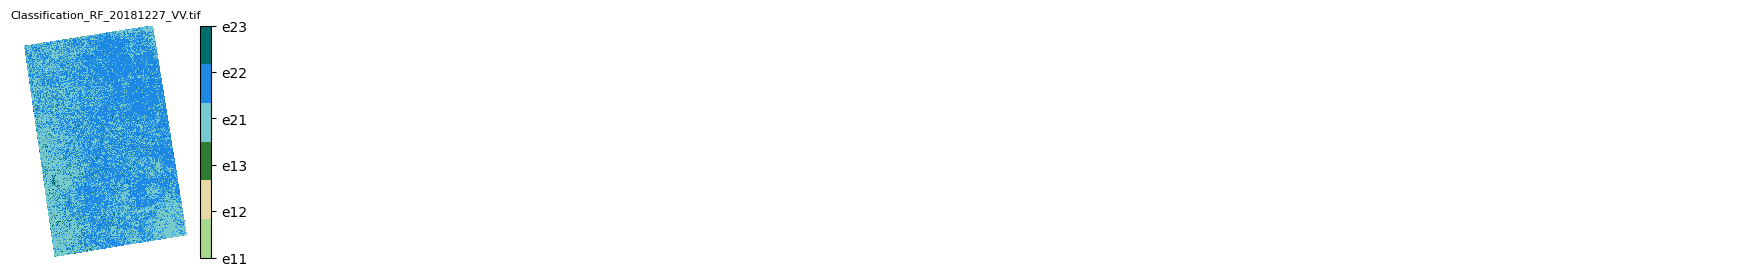

In [ ]:
visualizar_pronosticos_coloreado("/content", label_encoder=le, label_colors=label_colors)